<a href="https://colab.research.google.com/github/sriharshitha06/Machine-Learning/blob/main/youtube_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import zipfile
import os

zip_file_path = '/content/youtube_dataset.zip'
extraction_path = '/content/'

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)

print(f"Contents of {zip_file_path} extracted to {extraction_path}")

# List the extracted files to confirm
print("Extracted files:")
for item in os.listdir(extraction_path):
    print(item)

Contents of /content/youtube_dataset.zip extracted to /content/
Extracted files:
.config
KR_category_id.json
DEvideos.csv
CAvideos.csv
CA_category_id.json
DE_category_id.json
INvideos.csv
USvideos.csv
FRvideos.csv
US_category_id.json
MXvideos.csv
MX_category_id.json
RU_category_id.json
KRvideos.csv
IN_category_id.json
RUvideos.csv
GB_category_id.json
JPvideos.csv
FR_category_id.json
JP_category_id.json
GBvideos.csv
youtube_dataset.zip
sample_data


## Load and Combine Video Data

### Subtask:
Load all individual regional CSV files (e.g., 'USvideos.csv', 'GBvideos.csv', etc.) into pandas DataFrames and concatenate them into a single, comprehensive DataFrame for analysis.


In [2]:
import pandas as pd

all_video_dfs = []

for item in os.listdir(extraction_path):
    if item.endswith('videos.csv'):
        file_path = os.path.join(extraction_path, item)
        try:
            df = pd.read_csv(file_path)
            all_video_dfs.append(df)
            print(f"Loaded {item} with {len(df)} rows.")
        except Exception as e:
            print(f"Error loading {item}: {e}")

combined_videos_df = pd.concat(all_video_dfs, ignore_index=True)

print("\nCombined DataFrame head:")
print(combined_videos_df.head())

print("\nCombined DataFrame shape:")
print(combined_videos_df.shape)

Loaded DEvideos.csv with 40840 rows.
Loaded CAvideos.csv with 40881 rows.
Loaded INvideos.csv with 37352 rows.
Loaded USvideos.csv with 40949 rows.
Loaded FRvideos.csv with 40724 rows.
Error loading MXvideos.csv: 'utf-8' codec can't decode byte 0xc3 in position 130670: invalid continuation byte
Error loading KRvideos.csv: 'utf-8' codec can't decode bytes in position 261291-261292: invalid continuation byte
Error loading RUvideos.csv: 'utf-8' codec can't decode byte 0xd0 in position 364767: invalid continuation byte
Error loading JPvideos.csv: 'utf-8' codec can't decode bytes in position 215323-215324: invalid continuation byte
Loaded GBvideos.csv with 38916 rows.

Combined DataFrame head:
      video_id trending_date  \
0  LgVi6y5QIjM      17.14.11   
1  Bayt7uQith4      17.14.11   
2  1ZAPwfrtAFY      17.14.11   
3  AHtypnRk7JE      17.14.11   
4  ZJ9We4bjcg0      17.14.11   

                                               title            channel_title  \
0  Sing zu Ende! | Gesangsei

In [3]:
import pandas as pd
import os

all_video_dfs = []

# Assuming extraction_path is already defined from previous steps
# extraction_path = '/content/'

for item in os.listdir(extraction_path):
    if item.endswith('videos.csv'):
        file_path = os.path.join(extraction_path, item)
        try:
            df = pd.read_csv(file_path)
            all_video_dfs.append(df)
            print(f"Loaded {item} with {len(df)} rows using default encoding.")
        except UnicodeDecodeError:
            try:
                df = pd.read_csv(file_path, encoding='latin1')
                all_video_dfs.append(df)
                print(f"Loaded {item} with {len(df)} rows using latin1 encoding.")
            except Exception as e:
                print(f"Error loading {item} even with latin1: {e}")
        except Exception as e:
            print(f"Error loading {item}: {e}")

combined_videos_df = pd.concat(all_video_dfs, ignore_index=True)

print("\nCombined DataFrame head:")
print(combined_videos_df.head())

print("\nCombined DataFrame shape:")
print(combined_videos_df.shape)


Loaded DEvideos.csv with 40840 rows using default encoding.
Loaded CAvideos.csv with 40881 rows using default encoding.
Loaded INvideos.csv with 37352 rows using default encoding.
Loaded USvideos.csv with 40949 rows using default encoding.
Loaded FRvideos.csv with 40724 rows using default encoding.
Loaded MXvideos.csv with 40451 rows using latin1 encoding.
Loaded KRvideos.csv with 34567 rows using latin1 encoding.
Loaded RUvideos.csv with 40739 rows using latin1 encoding.
Loaded JPvideos.csv with 20523 rows using latin1 encoding.
Loaded GBvideos.csv with 38916 rows using default encoding.

Combined DataFrame head:
      video_id trending_date  \
0  LgVi6y5QIjM      17.14.11   
1  Bayt7uQith4      17.14.11   
2  1ZAPwfrtAFY      17.14.11   
3  AHtypnRk7JE      17.14.11   
4  ZJ9We4bjcg0      17.14.11   

                                               title            channel_title  \
0  Sing zu Ende! | Gesangseinlagen vom Feinsten |...                inscope21   
1  Kinder ferngesteuert

In [4]:
import json

# Construct the full path to a category JSON file
category_file_path = os.path.join(extraction_path, 'US_category_id.json')

# Load the JSON file
with open(category_file_path, 'r') as f:
    category_data = json.load(f)

# Extract category ID and title and create a mapping
category_id_to_name = {}
for item in category_data['items']:
    category_id = int(item['id'])
    category_name = item['snippet']['title']
    category_id_to_name[category_id] = category_name

# Print the first few items of the created category mapping dictionary to verify
print("First few items of category_id_to_name mapping:")
for i, (cat_id, cat_name) in enumerate(category_id_to_name.items()):
    if i >= 5:
        break
    print(f"  {cat_id}: {cat_name}")


First few items of category_id_to_name mapping:
  1: Film & Animation
  2: Autos & Vehicles
  10: Music
  15: Pets & Animals
  17: Sports


In [5]:
combined_videos_df['category_name'] = combined_videos_df['category_id'].map(category_id_to_name)

print("Combined DataFrame with category names (head):")
print(combined_videos_df.head())

Combined DataFrame with category names (head):
      video_id trending_date  \
0  LgVi6y5QIjM      17.14.11   
1  Bayt7uQith4      17.14.11   
2  1ZAPwfrtAFY      17.14.11   
3  AHtypnRk7JE      17.14.11   
4  ZJ9We4bjcg0      17.14.11   

                                               title            channel_title  \
0  Sing zu Ende! | Gesangseinlagen vom Feinsten |...                inscope21   
1  Kinder ferngesteuert im Kiosk! Erwachsene abzo...  LUKE! Die Woche und ich   
2  The Trump Presidency: Last Week Tonight with J...          LastWeekTonight   
3                                Das Fermi-Paradoxon        100SekundenPhysik   
4           18 SONGS mit Kelly MissesVlog (Sing-off)                     rezo   

   category_id              publish_time  \
0           24  2017-11-13T17:08:49.000Z   
1           23  2017-11-12T22:30:01.000Z   
2           24  2017-11-13T07:30:00.000Z   
3           27  2017-11-12T15:00:01.000Z   
4           24  2017-11-12T13:10:36.000Z   

        

In [6]:
print("Missing values per column:")
print(combined_videos_df.isnull().sum())

print("\nDataFrame Info (data types and non-null counts):")
combined_videos_df.info()

print("\nDescriptive statistics for numerical columns:")
print(combined_videos_df.describe())

Missing values per column:
video_id                      0
trending_date                 0
title                         0
channel_title                 0
category_id                   0
publish_time                  0
tags                          0
views                         0
likes                         0
dislikes                      0
comment_count                 0
thumbnail_link                0
comments_disabled             0
ratings_disabled              0
video_error_or_removed        0
description               19478
category_name                 0
dtype: int64

DataFrame Info (data types and non-null counts):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375942 entries, 0 to 375941
Data columns (total 17 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   video_id                375942 non-null  object
 1   trending_date           375942 non-null  object
 2   title                   375942 non-nul

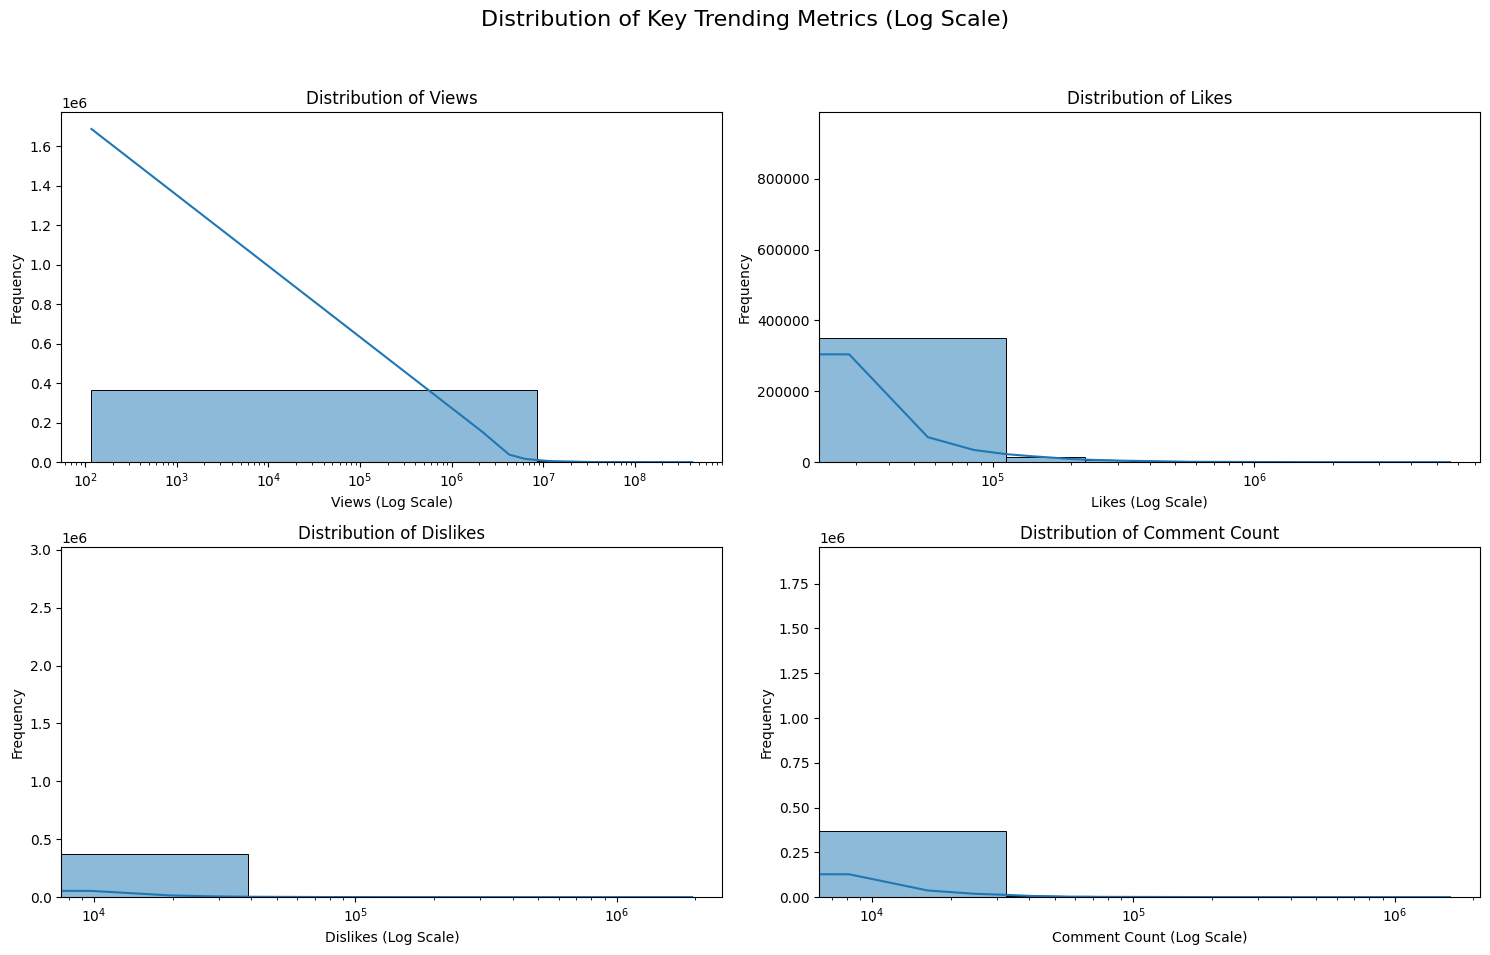

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure and a set of subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Distribution of Key Trending Metrics (Log Scale)', fontsize=16)

# List of metrics to visualize
metrics = ['views', 'likes', 'dislikes', 'comment_count']

# Flatten the axes array for easy iteration
axes = axes.flatten()

# Plot histograms for each metric
for i, metric in enumerate(metrics):
    sns.histplot(combined_videos_df[metric], bins=50, kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {metric.replace("_", " ").title()}')
    axes[i].set_xlabel(f'{metric.replace("_", " ").title()} (Log Scale)')
    axes[i].set_ylabel('Frequency')
    axes[i].set_xscale('log') # Set x-axis to logarithmic scale

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

In [8]:
import pandas as pd

# 1. Calculate top channels based on total views and unique trending videos
top_channels_df = combined_videos_df.groupby('channel_title').agg(
    total_views=('views', 'sum'),
    unique_trending_videos=('video_id', 'nunique')
).reset_index()

# Sort by total views and then by unique trending videos
top_channels_by_views = top_channels_df.sort_values(by='total_views', ascending=False).head(10)
top_channels_by_videos = top_channels_df.sort_values(by='unique_trending_videos', ascending=False).head(10)

print("\nTop 10 Channels by Total Views:")
print(top_channels_by_views)

print("\nTop 10 Channels by Unique Trending Videos:")
print(top_channels_by_videos)

# 2. Calculate top categories based on total views and unique trending videos
top_categories_df = combined_videos_df.groupby('category_name').agg(
    total_views=('views', 'sum'),
    unique_trending_videos=('video_id', 'nunique')
).reset_index()

# Sort by total views and then by unique trending videos
top_categories_by_views = top_categories_df.sort_values(by='total_views', ascending=False).head(10)
top_categories_by_videos = top_categories_df.sort_values(by='unique_trending_videos', ascending=False).head(10)

print("\nTop 10 Categories by Total Views:")
print(top_categories_by_views)

print("\nTop 10 Categories by Unique Trending Videos:")
print(top_categories_by_videos)


Top 10 Channels by Total Views:
              channel_title  total_views  unique_trending_videos
4590    ChildishGambinoVEVO  11016766510                       2
15599  Marvel Entertainment  10430605449                      27
17793            NickyJamTV   9479859505                       6
18533                 Ozuna   8623329509                       5
28519               ibighit   8205572221                      10
6724              DrakeVEVO   7637228580                       2
2801              Bad Bunny   7124207494                       3
2110       ArianaGrandeVevo   6202230488                       3
28728      jypentertainment   5802822913                      21
7084             Ed Sheeran   5775405574                       6

Top 10 Channels by Unique Trending Videos:
                            channel_title  total_views  unique_trending_videos
21093                           SET India    284502452                     254
20990                              SAB TV    11870

## Visualize Top Channels and Categories

### Subtask:
Create bar charts to visually represent the top channels and video categories, clearly labeling the axes and providing legends for better understanding.


**Reasoning**:
To visually represent the top channels and categories, I will generate four bar charts as instructed: top channels by total views, top channels by unique trending videos, top categories by total views, and top categories by unique trending videos. I will use `matplotlib.pyplot` and `seaborn` to create a 2x2 subplot grid, ensuring clear labels and titles for each plot.



/tmp/ipykernel_275/3873981412.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='total_views', y='channel_title', data=top_channels_by_views, ax=axes[0, 0], palette='viridis')
/tmp/ipykernel_275/3873981412.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='unique_trending_videos', y='channel_title', data=top_channels_by_videos, ax=axes[0, 1], palette='viridis')
/tmp/ipykernel_275/3873981412.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='total_views', y='category_name', data=top_categories_by_views, ax=axes[1, 0], palette='m

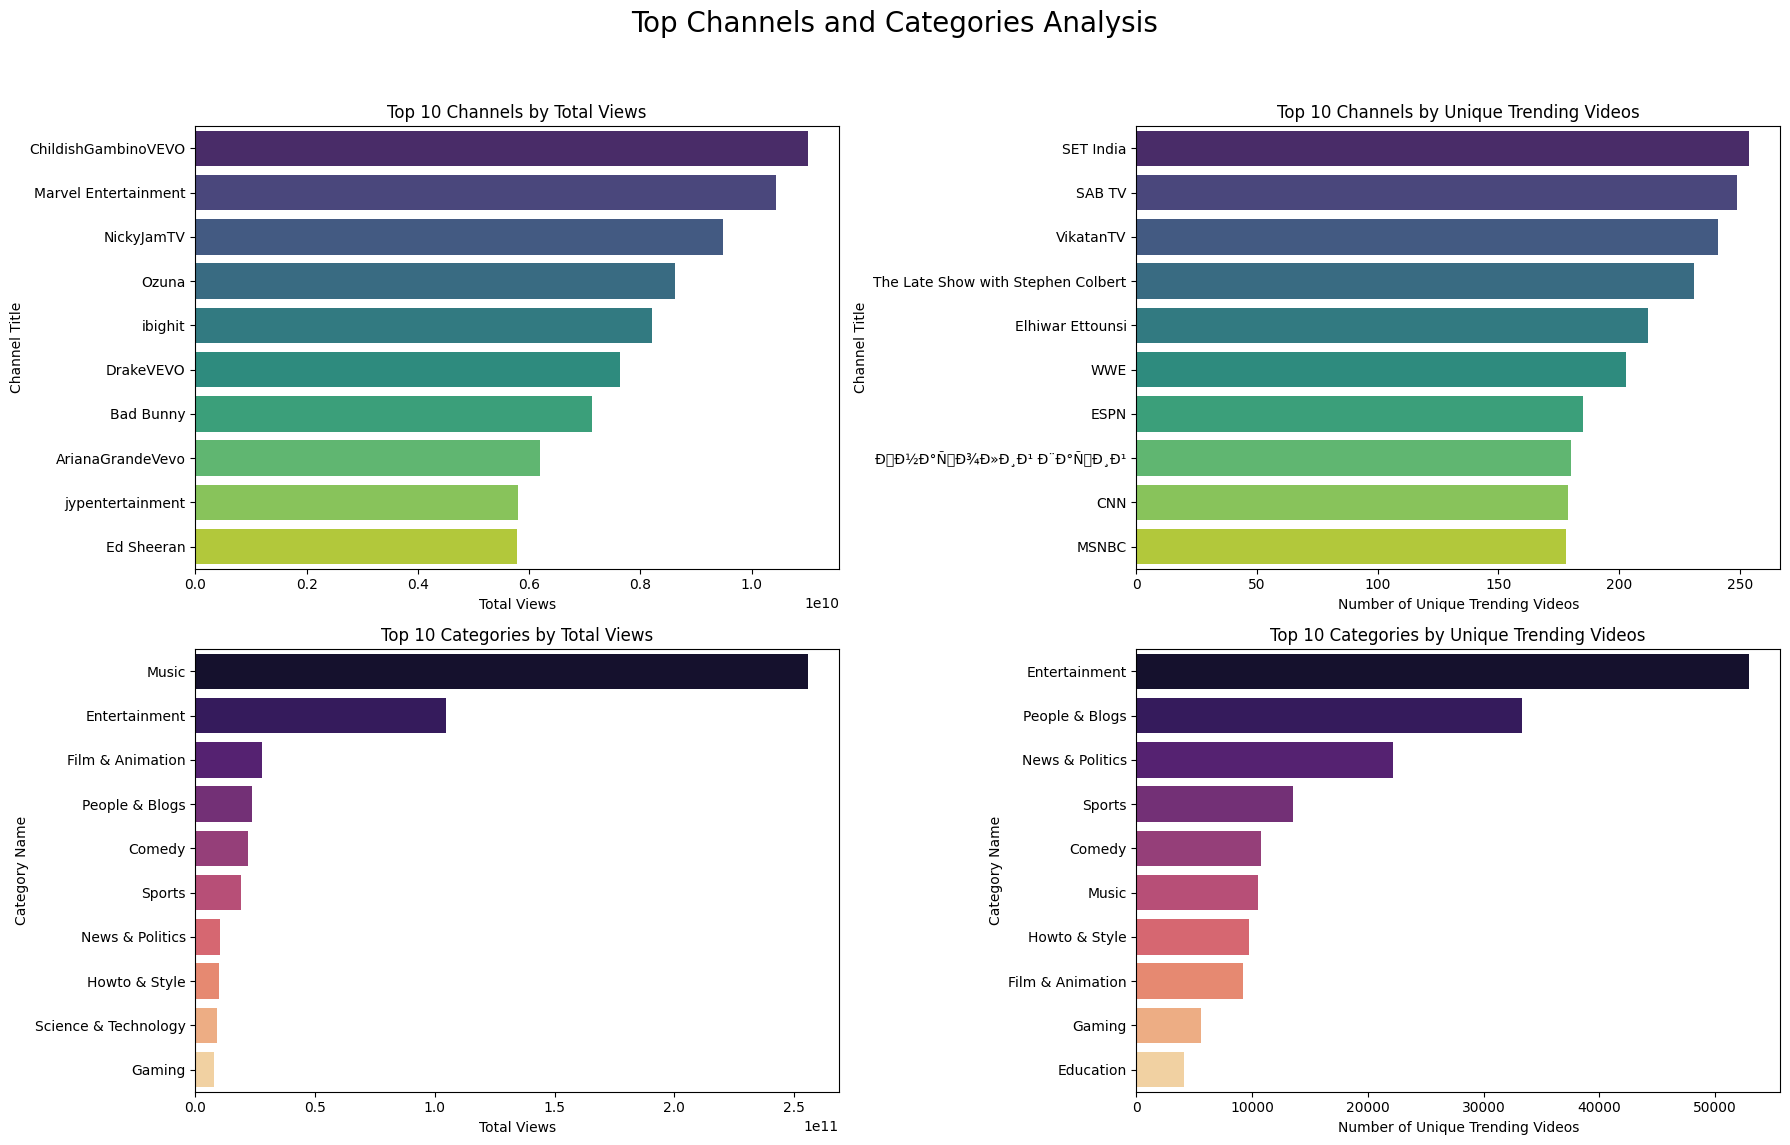

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with a 2x2 subplot layout
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Top Channels and Categories Analysis', fontsize=20)

# Plot 1: Top 10 Channels by Total Views
sns.barplot(x='total_views', y='channel_title', data=top_channels_by_views, ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title('Top 10 Channels by Total Views')
axes[0, 0].set_xlabel('Total Views')
axes[0, 0].set_ylabel('Channel Title')

# Plot 2: Top 10 Channels by Unique Trending Videos
sns.barplot(x='unique_trending_videos', y='channel_title', data=top_channels_by_videos, ax=axes[0, 1], palette='viridis')
axes[0, 1].set_title('Top 10 Channels by Unique Trending Videos')
axes[0, 1].set_xlabel('Number of Unique Trending Videos')
axes[0, 1].set_ylabel('Channel Title')

# Plot 3: Top 10 Categories by Total Views
sns.barplot(x='total_views', y='category_name', data=top_categories_by_views, ax=axes[1, 0], palette='magma')
axes[1, 0].set_title('Top 10 Categories by Total Views')
axes[1, 0].set_xlabel('Total Views')
axes[1, 0].set_ylabel('Category Name')

# Plot 4: Top 10 Categories by Unique Trending Videos
sns.barplot(x='unique_trending_videos', y='category_name', data=top_categories_by_videos, ax=axes[1, 1], palette='magma')
axes[1, 1].set_title('Top 10 Categories by Unique Trending Videos')
axes[1, 1].set_xlabel('Number of Unique Trending Videos')
axes[1, 1].set_ylabel('Category Name')

# Adjust layout to prevent overlapping titles/labels
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

/tmp/ipykernel_275/635051413.py:37: UserWarning: Glyph 144 (\x90) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])
/tmp/ipykernel_275/635051413.py:37: UserWarning: Glyph 130 (\x82) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])
/tmp/ipykernel_275/635051413.py:37: UserWarning: Glyph 128 (\x80) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 144 (\x90) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 130 (\x82) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128 (\x80) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


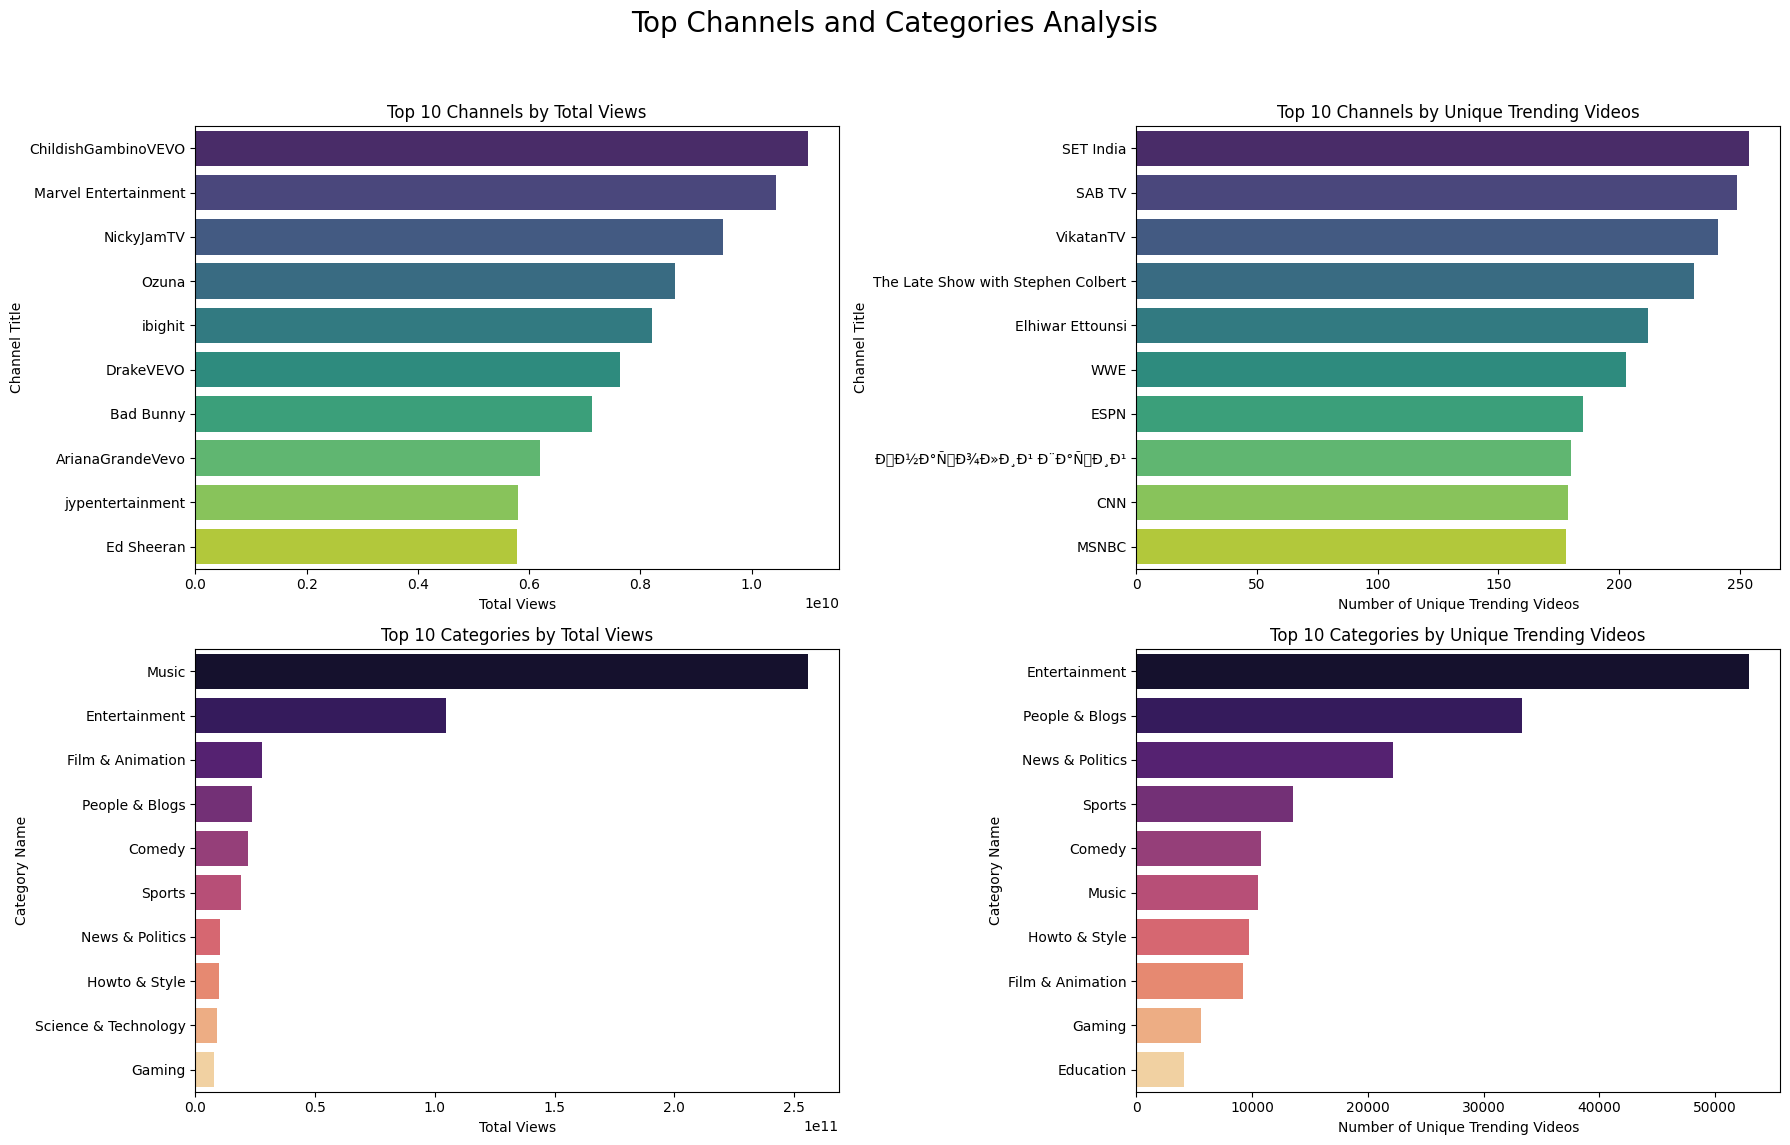

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configure matplotlib to handle unicode characters, to prevent Glyph warnings
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial Unicode MS'] # Fallback fonts
plt.rcParams['axes.unicode_minus'] = False # Ensure minus signs are rendered correctly

# Create a figure with a 2x2 subplot layout
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Top Channels and Categories Analysis', fontsize=20)

# Plot 1: Top 10 Channels by Total Views
sns.barplot(x='total_views', y='channel_title', data=top_channels_by_views, ax=axes[0, 0], palette='viridis', hue='channel_title', legend=False)
axes[0, 0].set_title('Top 10 Channels by Total Views')
axes[0, 0].set_xlabel('Total Views')
axes[0, 0].set_ylabel('Channel Title')

# Plot 2: Top 10 Channels by Unique Trending Videos
sns.barplot(x='unique_trending_videos', y='channel_title', data=top_channels_by_videos, ax=axes[0, 1], palette='viridis', hue='channel_title', legend=False)
axes[0, 1].set_title('Top 10 Channels by Unique Trending Videos')
axes[0, 1].set_xlabel('Number of Unique Trending Videos')
axes[0, 1].set_ylabel('Channel Title')

# Plot 3: Top 10 Categories by Total Views
sns.barplot(x='total_views', y='category_name', data=top_categories_by_views, ax=axes[1, 0], palette='magma', hue='category_name', legend=False)
axes[1, 0].set_title('Top 10 Categories by Total Views')
axes[1, 0].set_xlabel('Total Views')
axes[1, 0].set_ylabel('Category Name')

# Plot 4: Top 10 Categories by Unique Trending Videos
sns.barplot(x='unique_trending_videos', y='category_name', data=top_categories_by_videos, ax=axes[1, 1], palette='magma', hue='category_name', legend=False)
axes[1, 1].set_title('Top 10 Categories by Unique Trending Videos')
axes[1, 1].set_xlabel('Number of Unique Trending Videos')
axes[1, 1].set_ylabel('Category Name')

# Adjust layout to prevent overlapping titles/labels
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

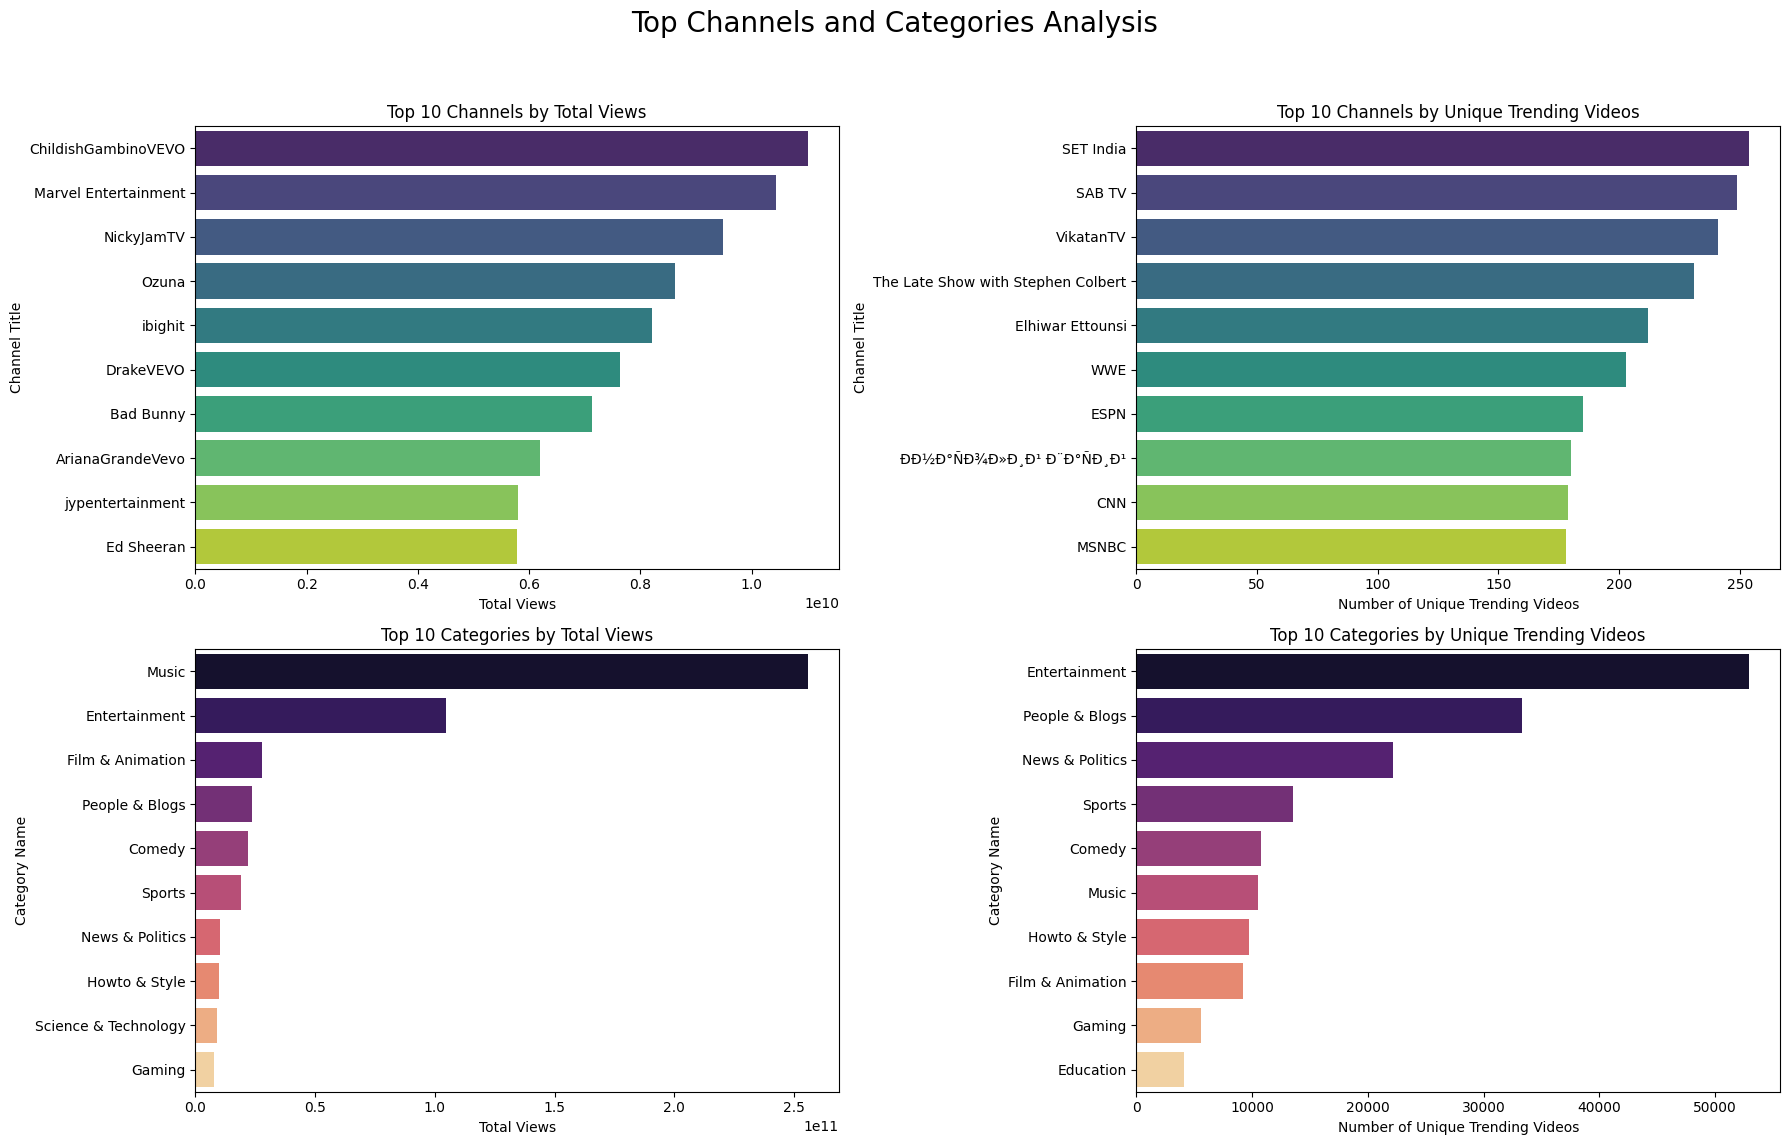

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import unicodedata # For cleaning strings

# Configure matplotlib to handle unicode characters, to prevent Glyph warnings
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial Unicode MS'] # Fallback fonts
plt.rcParams['axes.unicode_minus'] = False # Ensure minus signs are rendered correctly

# Function to remove control characters from a string
def remove_control_chars(text):
    if isinstance(text, str):
        # This will remove C0 and C1 control characters (e.g., -) that often cause glyph errors
        return "".join(ch for ch in text if unicodedata.category(ch)[0] != "C")
    return text

# Apply cleaning to the relevant DataFrame columns that are used for plotting
top_channels_by_views['channel_title'] = top_channels_by_views['channel_title'].apply(remove_control_chars)
top_channels_by_videos['channel_title'] = top_channels_by_videos['channel_title'].apply(remove_control_chars)
top_categories_by_views['category_name'] = top_categories_by_views['category_name'].apply(remove_control_chars)
top_categories_by_videos['category_name'] = top_categories_by_videos['category_name'].apply(remove_control_chars)

# Create a figure with a 2x2 subplot layout
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Top Channels and Categories Analysis', fontsize=20)

# Plot 1: Top 10 Channels by Total Views
sns.barplot(x='total_views', y='channel_title', data=top_channels_by_views, ax=axes[0, 0], palette='viridis', hue='channel_title', legend=False)
axes[0, 0].set_title('Top 10 Channels by Total Views')
axes[0, 0].set_xlabel('Total Views')
axes[0, 0].set_ylabel('Channel Title')

# Plot 2: Top 10 Channels by Unique Trending Videos
sns.barplot(x='unique_trending_videos', y='channel_title', data=top_channels_by_videos, ax=axes[0, 1], palette='viridis', hue='channel_title', legend=False)
axes[0, 1].set_title('Top 10 Channels by Unique Trending Videos')
axes[0, 1].set_xlabel('Number of Unique Trending Videos')
axes[0, 1].set_ylabel('Channel Title')

# Plot 3: Top 10 Categories by Total Views
sns.barplot(x='total_views', y='category_name', data=top_categories_by_views, ax=axes[1, 0], palette='magma', hue='category_name', legend=False)
axes[1, 0].set_title('Top 10 Categories by Total Views')
axes[1, 0].set_xlabel('Total Views')
axes[1, 0].set_ylabel('Category Name')

# Plot 4: Top 10 Categories by Unique Trending Videos
sns.barplot(x='unique_trending_videos', y='category_name', data=top_categories_by_videos, ax=axes[1, 1], palette='magma', hue='category_name', legend=False)
axes[1, 1].set_title('Top 10 Categories by Unique Trending Videos')
axes[1, 1].set_xlabel('Number of Unique Trending Videos')
axes[1, 1].set_ylabel('Category Name')

# Adjust layout to prevent overlapping titles/labels
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [12]:
import numpy as np

# Calculate 'likes_per_view' and handle division by zero
combined_videos_df['likes_per_view'] = combined_videos_df['likes'] / combined_videos_df['views']
combined_videos_df['likes_per_view'] = combined_videos_df['likes_per_view'].replace([np.inf, -np.inf], np.nan).fillna(0)

# Calculate 'comments_per_view' and handle division by zero
combined_videos_df['comments_per_view'] = combined_videos_df['comment_count'] / combined_videos_df['views']
combined_videos_df['comments_per_view'] = combined_videos_df['comments_per_view'].replace([np.inf, -np.inf], np.nan).fillna(0)

print("Descriptive statistics for engagement ratios:")
print(combined_videos_df[['likes_per_view', 'comments_per_view']].describe())

print("\nFirst few rows of DataFrame with new engagement ratios:")
print(combined_videos_df[['views', 'likes', 'comment_count', 'likes_per_view', 'comments_per_view']].head())

Descriptive statistics for engagement ratios:
       likes_per_view  comments_per_view
count   375942.000000      375942.000000
mean         0.035617           0.005488
std          0.037380           0.009812
min          0.000000           0.000000
25%          0.008036           0.001190
50%          0.022889           0.002928
75%          0.051690           0.006370
max          0.942888           0.599004

First few rows of DataFrame with new engagement ratios:
     views   likes  comment_count  likes_per_view  comments_per_view
0   252786   35885           1539        0.141958           0.006088
1   797196   53576           1278        0.067206           0.001603
2  2418783   97190          12703        0.040181           0.005252
3   380247   31821           1955        0.083685           0.005141
4   822213  100684          10244        0.122455           0.012459


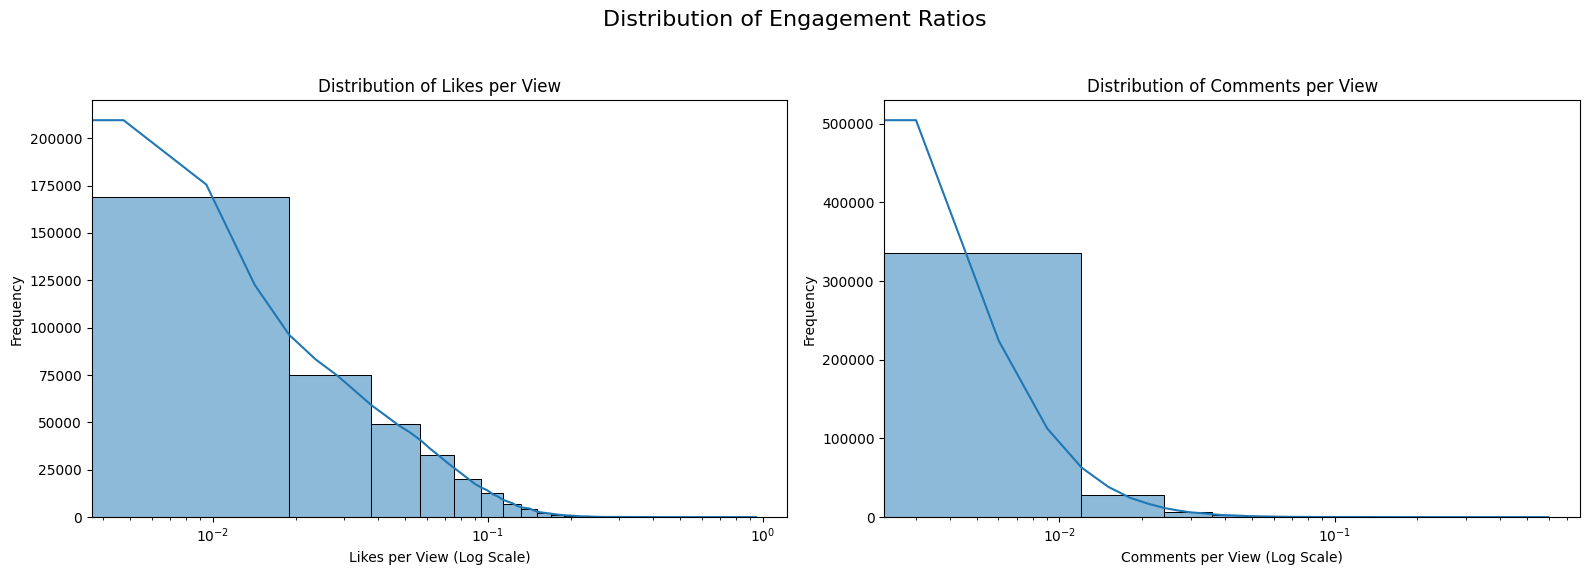

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Create a figure with a 1x2 subplot layout
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Distribution of Engagement Ratios', fontsize=16)

# Plot 1: Distribution of Likes per View
sns.histplot(combined_videos_df['likes_per_view'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Distribution of Likes per View')
axes[0].set_xlabel('Likes per View (Log Scale)')
axes[0].set_ylabel('Frequency')
# Using a small offset to handle zero values for log scale
axes[0].set_xscale('log')

# Plot 2: Distribution of Comments per View
sns.histplot(combined_videos_df['comments_per_view'], bins=50, kde=True, ax=axes[1])
axes[1].set_title('Distribution of Comments per View')
axes[1].set_xlabel('Comments per View (Log Scale)')
axes[1].set_ylabel('Frequency')
# Using a small offset to handle zero values for log scale
axes[1].set_xscale('log')

# Adjust layout to prevent overlapping titles/labels
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Summary:

### Data Analysis Key Findings

*   The dataset was successfully compiled from regional YouTube trending video CSV files into a single DataFrame containing 375,942 entries and 17 columns.
*   The `description` column had a significant number of missing values (19,478), while all other columns were complete.
*   Numerical columns such as `views`, `likes`, `dislikes`, and `comment_count` exhibited highly skewed distributions, with values ranging from very small to extremely large (e.g., `views` from 117 to over 424 million), indicating a few viral videos.
*   **Top Channels by Total Views**: Channels like ChildishGambinoVEVO, NickyJamTV, and Ozuna dominated by total views, with ChildishGambinoVEVO leading with over 11 billion views from only 2 unique trending videos, suggesting high view counts per video.
*   **Top Channels by Unique Trending Videos**: Channels such as SET India (254 unique videos), SAB TV, and VikatanTV consistently appeared in trending lists, demonstrating a high volume of trending content.
*   **Top Categories by Total Views**: "Music" and "Entertainment" were overwhelmingly dominant, accumulating over 255 billion and 104 billion total views, respectively.
*   **Top Categories by Unique Trending Videos**: "Entertainment" (52,961 unique videos), "People & Blogs" (33,280 unique videos), and "News & Politics" (22,198 unique videos) produced the most diverse range of trending content.
*   **Engagement Ratios**:
    *   The average `likes_per_view` was approximately 0.0356 (3.56%), with a maximum of 0.9429 (94.29%), indicating some videos garnered almost one like per view.
    *   The average `comments_per_view` was significantly lower at approximately 0.0055 (0.55%), though some videos reached a maximum of 0.5990 (59.90%) comments per view.
    *   Both engagement ratios showed highly skewed distributions, implying that a small fraction of videos achieved exceptionally high engagement relative to their view counts.

